In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [3]:
!pip install fairlearn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 251.6/251.6 kB 7.6 MB/s eta 0:00:00


sensitive_feature_0
cs         0.500000
physics    0.464286
Name: selection_rate, dtype: float64


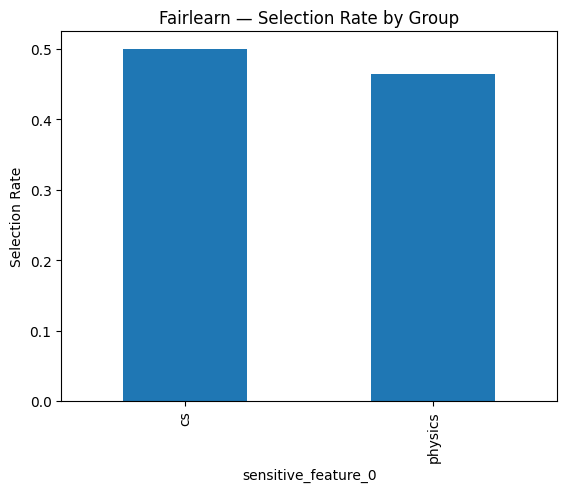

In [4]:
from fairlearn.metrics import MetricFrame, selection_rate
import numpy as np
import matplotlib.pyplot as plt

# Fake labels & predictions
y_true = np.random.randint(0, 2, 100)
y_pred = np.random.randint(0, 2, 100)

# Synthetic sensitive attribute (group membership)
groups = np.random.choice(['physics', 'cs'], size=100)

# Fairness metric
mf = MetricFrame(
    metrics=selection_rate,
    y_true=y_true,
    y_pred=y_pred,
    sensitive_features=groups
)

print(mf.by_group)

mf.by_group.plot(kind="bar")
plt.title("Fairlearn — Selection Rate by Group")
plt.ylabel("Selection Rate")
plt.show()


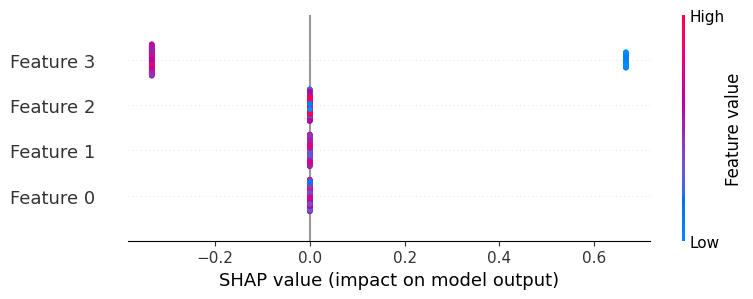

In [5]:
import shap
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier

# Load dataset
X, y = load_iris(return_X_y=True)

# Train a small model
model = DecisionTreeClassifier().fit(X, y)

# SHAP explainer
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X)

# Summary plot
shap.summary_plot(shap_values[0], X)
